In [32]:
import pandas as pd
import time 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [33]:
data_path = "gaming_addiction.csv"

df = pd.read_csv(data_path)

df.head(12)

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.00,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.00,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.00,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.00,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.00,0.585,0.867
5,USR000006,13,Male,USA,Freelancer,Middle,1,Horror,PC,Mobile,...,3,93.8,3.7,Casual Enjoyer,17.26,0,NaN,0.32,0.400,0.150
6,USR000007,27,Male,UK,Unemployed,Lower-Middle,15,RPG,Console,Console,...,12,5.0,10.0,Toxic Competitor,34.82,0,Mild,1.00,0.550,0.879
7,USR000008,18,Non-binary,Canada,Student,Middle,6,MOBA,PC,Mixed,...,5,97.1,4.7,Casual Enjoyer,22.66,0,Mild,1.00,0.490,0.825
8,USR000009,16,Female,USA,Student,High,1,Sports,Mobile,Mixed,...,5,81.9,11.0,Toxic Competitor,35.08,0,Mild,1.00,0.400,0.928
9,USR000010,30,Female,Brazil,Freelancer,Middle,18,Strategy,Console,Mid-range PC,...,3,22.2,7.5,Competitive Grinder,46.24,0,Moderate,1.00,0.290,0.756


In [34]:
# Dropping user_id we dont use it
df = df.drop(['user_id'], axis=1)

In [35]:

print(df.columns.to_list())
print(df.dtypes)

print("Reading data null : ",df.isnull().sum().max())



['age', 'gender', 'country', 'occupation', 'income_level', 'years_gaming', 'preferred_genre', 'platform', 'device_type', 'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions', 'late_night_sessions_hours', 'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd', 'lootbox_openings', 'subscription_status', 'stress_score', 'loneliness_score', 'dopamine_dependency_index', 'self_control_score', 'impulsiveness_score', 'anxiety_level', 'depression_indicator', 'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week', 'caffeine_intake_cups_day', 'social_interaction_hours', 'relationship_status', 'gpa_or_performance_score', 'missed_deadlines', 'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps', 'screen_time_total_hours', 'behavioral_cluster', 'addiction_score', 'addiction_binary', 'addiction_severity', 'burnout_probability', 'mental_health_risk_score', 'chu

subscription_status         82
depression_indicator        11
gpa_or_performance_score    10
addiction_severity          16
dtype: int64


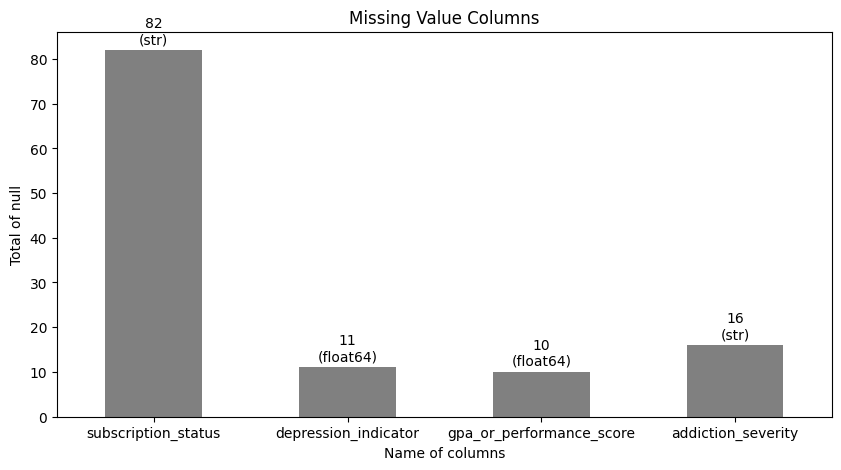

In [51]:
# Searching for null fields

missing_value = df.isnull().sum()[df.isnull().sum() > 0]

missing_types = df[missing_value.index].dtypes

print(df.isnull().sum()[df.isnull().sum() > 0])

plt.figure(figsize=(10,5))

ax = missing_value.plot.bar(color='gray')

for i, col in enumerate(missing_value.index):
    count = missing_value[col]
    dtype = missing_types[col]

    ax.text(i, count + (max(missing_value) * 0.01), f"{count}\n({dtype})", ha='center', va='bottom')

plt.title("Missing Value Columns")
plt.xlabel("Name of columns")
plt.ylabel("Total of null")
plt.xticks(rotation=0)
plt.show()

In [55]:
# Fixing missing value with SimpleImputer for numerical and catergory

# Numerical -> Median
num_imputer = SimpleImputer(strategy='median')
num_cols = ['depression_indicator', 'gpa_or_performance_score']
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Catergorial -> Modus 
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = ['subscription_status', 'addiction_severity']
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Updating missing value : ", df.isnull().sum().max())



Updating missing value :  0
